# Stage Movement and Sample Mapping

Move the stage, acquire overview images, and return to the starting position while mapping the sample.


### Run the servers

Make sure you are on the VPN and the AutoScript server is running. Then start the asyncroscopy Tango servers from the repository root:

```bash
uv run startup_scripts/run_servers.py
```


### Imports


In [1]:
import os
import json
import time

import tango
import numpy as np
import matplotlib.pyplot as plt
from tiled.client import from_uri

%matplotlib ipympl


### Ping servers


In [3]:
DB_HOST = "10.46.217.241"
# DB_HOST = "localhost"
DB_PORT = 9094

os.environ["TANGO_HOST"] = f"{DB_HOST}:{DB_PORT}"

scan = tango.DeviceProxy("asyncroscopy/scan/default")
microscope = tango.DeviceProxy("asyncroscopy/instrument/default")
data = tango.DeviceProxy("asyncroscopy/data/default")

for proxy in [scan, microscope, data]:
    proxy.set_timeout_millis(120_000)
    proxy.ping()
    print(proxy.name(), proxy.state())

asyncroscopy/scan/default ON
asyncroscopy/instrument/default ON
asyncroscopy/data/default ON


### Set Tiled Client


In [4]:
config = json.loads(data.get_config())
config

{'host': '10.46.217.241',
 'port': 9091,
 'uri': 'http://10.46.217.241:9091',
 'save_path': 'outputs/tiled_acquisitions',
 'tiled_server': 'yes',
 'tiled_server_status': 'running; serving path; files register manually',
 'tiled_server_serving': 'outputs/tiled_acquisitions'}

In [5]:
client = from_uri(config.get("uri"))
print("Tiled keys:", list(client))

Tiled keys: ['stem_image_HAADF_20260710T131230285541.h5', 'stem_image_HAADF_20260713T141126464167.h5', 'stem_image_HAADF_20260713T141208901682.h5', 'stem_image_HAADF_20260713T141236251654.h5', 'stem_image_HAADF_BF-S_DF-S_20260713T141338120877.h5', 'stem_image_HAADF_20260713T144216432175.h5', 'stem_image_HAADF_BF-S_DF-S_20260713T144318424497.h5']


### Configure the scan


In [6]:
scan.dwell_time   = 1e-6  # µs
scan.imsize  = 512
scan.output_format = ".h5"

print('dwell_time  :', scan.dwell_time)
print('image size :', scan.imsize)


dwell_time  : 1e-06
image size : 512


### Set the field of view


In [7]:
# fov cutoff is 0.52e-9
fov = 0.52e-5
microscope.set_fov(fov)

### Acquire a reference image


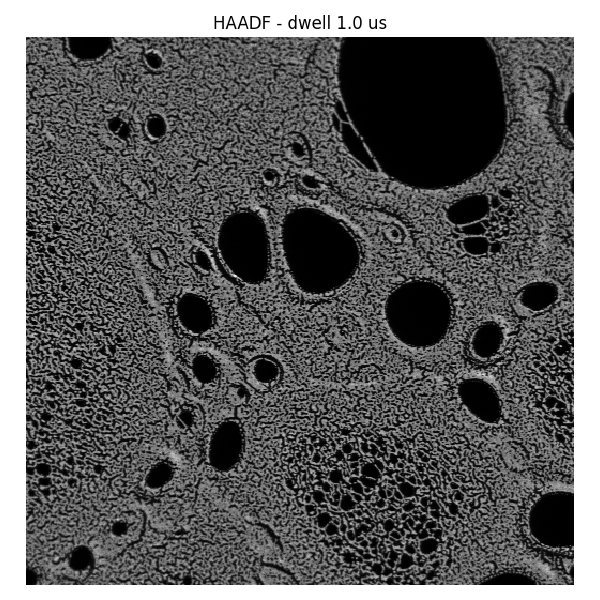

In [8]:
data_key = microscope.acquire_scanned_image(["haadf"])
image = client[data_key]["image"]["HAADF"].read()
metadata = dict(client[data_key]["image"]["HAADF"].metadata)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image, cmap="gray", interpolation="none")
ax.set_title(f"HAADF - dwell {scan.dwell_time * 1e6:.1f} us")
ax.axis("off")
plt.tight_layout()

### Read the current stage position


In [9]:
# get the stage
starting_position = microscope.get_stage()
print('Stage position:', starting_position)


Stage position: [0. 0. 0. 0. 0.]


### Move the stage


In [ ]:
# move the stage
move_by = -10e-6  # 10 µm

# for single tilt holder
# new_position = starting_position + np.array([move_by, 0, 0, 0])

# for double tilt holder
new_position = starting_position + np.array([move_by, 0, 0, 0, 0])

In [24]:
new_position

array([-5.07412985e-05,  4.45847254e-04, -1.31280962e-04,  1.28000858e-03,
        8.30517635e-02])

In [25]:
microscope.move_stage(new_position)

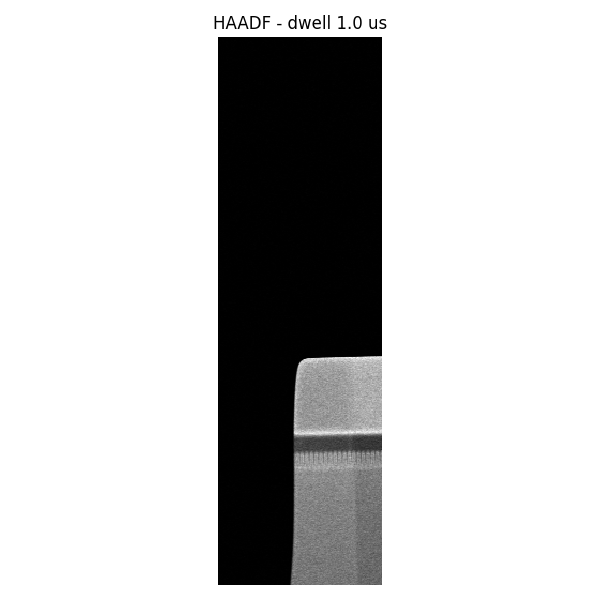

In [26]:
data_key = microscope.acquire_scanned_image(["haadf"])
image = client[data_key]["image"]["HAADF"].read()
metadata = dict(client[data_key]["image"]["HAADF"].metadata)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image, cmap="gray", interpolation="none")
ax.set_title(f"HAADF - dwell {scan.dwell_time * 1e6:.1f} us")
ax.axis("off")
plt.tight_layout()

### Return to the starting position


In [19]:
microscope.move_stage(starting_position)

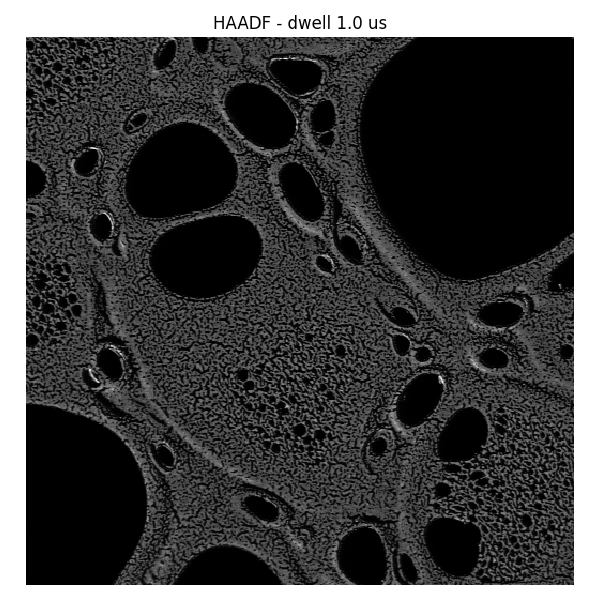

In [20]:
data_key = microscope.acquire_scanned_image(["haadf"])
image = client[data_key]["image"]["HAADF"].read()
metadata = dict(client[data_key]["image"]["HAADF"].metadata)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image, cmap="gray", interpolation="none")
ax.set_title(f"HAADF - dwell {scan.dwell_time * 1e6:.1f} us")
ax.axis("off")
plt.tight_layout()